In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import random
from zonolayer import compute_zonolayer_bounds

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Example 1

In [2]:
class RegressionNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=12):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.regressor = nn.Linear(hidden_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        
        if return_features:
            return out, features
        return out
    
class ZonoLayer(nn.Module):
    def __init__(self, hidden_dim=12, zono_dim=3):
        super().__init__()
        self.linear = nn.Linear(hidden_dim, zono_dim)

    def forward(self, features):
        return self.linear(features)
    

def train_centre(x_t, y_lb_t, y_ub_t, epochs=8000, lr=0.01, print_every=50):
    y_mid = (y_lb_t + y_ub_t) / 2

    centre_net = RegressionNetwork(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        pred = centre_net(x_t)
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")

    return centre_net

def train_zonolayer(centre_net, x_t, y_lb_t, y_ub_t, zono_dim=3, epochs=300, lr=1e-2, print_every=50):
    for p in centre_net.parameters():
        p.requires_grad = False
    centre_net.eval()

    with torch.no_grad():
        _, features = centre_net(x_t, return_features=True)

    hidden_dim = centre_net.regressor.in_features
    y_mid = (y_lb_t + y_ub_t) / 2

    zono_layer = ZonoLayer(hidden_dim=hidden_dim, zono_dim=zono_dim)

    with torch.no_grad():
        zono_layer.linear.weight[0:1, :] = centre_net.regressor.weight.data
        zono_layer.linear.bias[0:1]      = centre_net.regressor.bias.data

    optimizer = torch.optim.Adam(zono_layer.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        zono_layer.train()
        pred = zono_layer(features)[:, 0:1]
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Zono epoch {epoch+1}: MSE = {loss.item():.6f}")

    return zono_layer

In [3]:
df = pd.read_csv("Data/input_data.txt", sep="\t", header=None, names=["x", "y_lower", "y_upper"])
x = df["x"].to_numpy().reshape(-1, 1)
y_lower = df["y_lower"].to_numpy().reshape(-1, 1)
y_upper = df["y_upper"].to_numpy().reshape(-1, 1)

x_t = torch.tensor(x, dtype=torch.float32)
y_lb_t = torch.tensor(y_lower, dtype=torch.float32)
y_ub_t = torch.tensor(y_upper, dtype=torch.float32)
x_grid = np.linspace(0, 1, 200).reshape(-1, 1)


def extract_zono_predictions(centre_net, zono_layer, x):
    centre_net.eval()
    zono_layer.eval()
    with torch.no_grad():
        pred, features = centre_net(x, return_features=True)
        features = zono_layer(features)
    return pred.numpy(), features.numpy()

# Zonolayer computation
centre_net = train_centre(x_t, y_lb_t, y_ub_t)
zono_layer = train_zonolayer(centre_net, x_t, y_lb_t, y_ub_t, zono_dim=3)


pred_train, latent_train = extract_zono_predictions(centre_net, zono_layer, x_t)
pred_test, latent_test = extract_zono_predictions(centre_net, zono_layer, torch.tensor(x_grid, dtype=torch.float32))
zonolayer = compute_zonolayer_bounds(latent_train, y_lower, y_upper, latent_test)

Epoch 50: MSE = 0.018234
Epoch 100: MSE = 0.013410
Epoch 150: MSE = 0.003786
Epoch 200: MSE = 0.001503
Epoch 250: MSE = 0.001092
Epoch 300: MSE = 0.000856
Epoch 350: MSE = 0.000710
Epoch 400: MSE = 0.000620
Epoch 450: MSE = 0.000566
Epoch 500: MSE = 0.000534
Epoch 550: MSE = 0.000513
Epoch 600: MSE = 0.000500
Epoch 650: MSE = 0.000491
Epoch 700: MSE = 0.000484
Epoch 750: MSE = 0.000479
Epoch 800: MSE = 0.000475
Epoch 850: MSE = 0.000471
Epoch 900: MSE = 0.000469
Epoch 950: MSE = 0.000466
Epoch 1000: MSE = 0.000464
Epoch 1050: MSE = 0.000462
Epoch 1100: MSE = 0.000460
Epoch 1150: MSE = 0.000458
Epoch 1200: MSE = 0.000457
Epoch 1250: MSE = 0.000455
Epoch 1300: MSE = 0.000454
Epoch 1350: MSE = 0.000453
Epoch 1400: MSE = 0.000452
Epoch 1450: MSE = 0.000450
Epoch 1500: MSE = 0.000449
Epoch 1550: MSE = 0.000448
Epoch 1600: MSE = 0.000447
Epoch 1650: MSE = 0.000446
Epoch 1700: MSE = 0.000445
Epoch 1750: MSE = 0.000444
Epoch 1800: MSE = 0.000443
Epoch 1850: MSE = 0.000441
Epoch 1900: MSE = 0.0

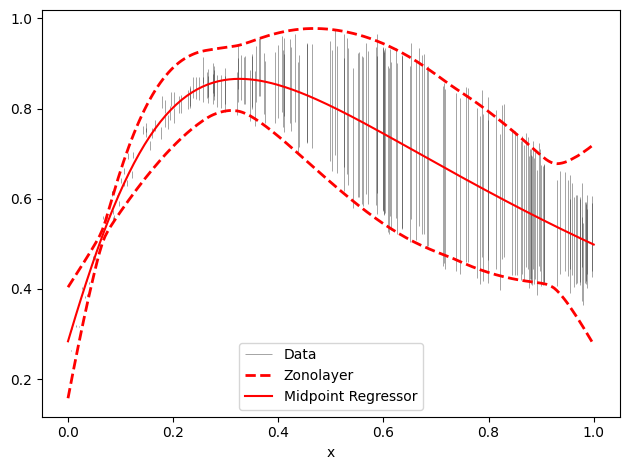

In [4]:
yl_zl = zonolayer["y_lower"]
yu_zl = zonolayer["y_upper"]
midpoint_model = zonolayer["midpoint"]

plt.figure()

x_plot = x_grid.squeeze()
sorted_idx = np.argsort(x_plot)

y_lower_data = y_lower[sorted_idx].squeeze()
y_upper_data = y_upper[sorted_idx].squeeze()

x_plot = x_plot[sorted_idx]
yl_zl = yl_zl[sorted_idx].squeeze()
yu_zl = yu_zl[sorted_idx].squeeze()

plt.vlines(x, y_lower_data, y_upper_data,
           color='black', alpha=0.5, linewidth=0.5, label='Data')

plt.plot(x_plot, yl_zl, 'r--', lw=2, label='Zonolayer')
plt.plot(x_plot, yu_zl, 'r--', lw=2)

plt.plot(x_plot, pred_test, 'r-', lw=1.5, label='Midpoint Regressor')

plt.xlabel("x")
plt.legend()
plt.tight_layout()

plt.savefig("ArtificalDataset1.pdf", bbox_inches="tight")
plt.show()

## Example 2

In [5]:
class RegressionNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=8, zono_dim=3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, zono_dim)
        )
        self.regressor = nn.Linear(zono_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        if return_features:
            return out, features
        return out


def train_centre(x_t, y_lb_t, y_ub_t, epochs=8000, lr=0.01, print_every=50):
    y_mid = (y_lb_t + y_ub_t) / 2

    centre_net = RegressionNetwork(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        pred = centre_net(x_t)
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")

    return centre_net

def artificial_dataset(n):
    x = np.random.rand(n).reshape(-1, 1)
    y = np.sin(2 * np.pi * x**2) * np.exp(-x) + \
        1 + np.random.normal(0, 0.15, (n, 1))
    rad = np.abs(np.random.normal(0.1, 0.05, (n, 1)))
    return x, y, y - rad, y + rad

x, y, y_lower, y_upper = artificial_dataset(400)

In [6]:
def extract_latent_features(model, x):
    model.eval()
    with torch.no_grad():
        preds, features = model(x, return_features=True)
    return preds.cpu().numpy(), features.cpu().numpy()

x_t = torch.tensor(x, dtype=torch.float32)
y_lb_t = torch.tensor(y_lower, dtype=torch.float32)
y_ub_t = torch.tensor(y_upper, dtype=torch.float32)
x_grid = np.linspace(0, 1, 400).reshape(-1, 1)

centre_net = train_centre(x_t, y_lb_t, y_ub_t)
pred_train, latent_train = extract_latent_features(centre_net, x_t)
pred_test, latent_test = extract_latent_features(centre_net, torch.tensor(x_grid, dtype=torch.float32))

zonolayer = compute_zonolayer_bounds(latent_train, y_lower, y_upper, latent_test)

Epoch 50: MSE = 0.119155
Epoch 100: MSE = 0.109526
Epoch 150: MSE = 0.107378
Epoch 200: MSE = 0.104372
Epoch 250: MSE = 0.098541
Epoch 300: MSE = 0.083865
Epoch 350: MSE = 0.054898
Epoch 400: MSE = 0.037730
Epoch 450: MSE = 0.035453
Epoch 500: MSE = 0.034019
Epoch 550: MSE = 0.032868
Epoch 600: MSE = 0.031877
Epoch 650: MSE = 0.030990
Epoch 700: MSE = 0.030183
Epoch 750: MSE = 0.029444
Epoch 800: MSE = 0.028771
Epoch 850: MSE = 0.028166
Epoch 900: MSE = 0.027628
Epoch 950: MSE = 0.027161
Epoch 1000: MSE = 0.026761
Epoch 1050: MSE = 0.026423
Epoch 1100: MSE = 0.026137
Epoch 1150: MSE = 0.025893
Epoch 1200: MSE = 0.025679
Epoch 1250: MSE = 0.025489
Epoch 1300: MSE = 0.025314
Epoch 1350: MSE = 0.025151
Epoch 1400: MSE = 0.024995
Epoch 1450: MSE = 0.024843
Epoch 1500: MSE = 0.024690
Epoch 1550: MSE = 0.024534
Epoch 1600: MSE = 0.024373
Epoch 1650: MSE = 0.024203
Epoch 1700: MSE = 0.024046
Epoch 1750: MSE = 0.023882
Epoch 1800: MSE = 0.023715
Epoch 1850: MSE = 0.023627
Epoch 1900: MSE = 0.0

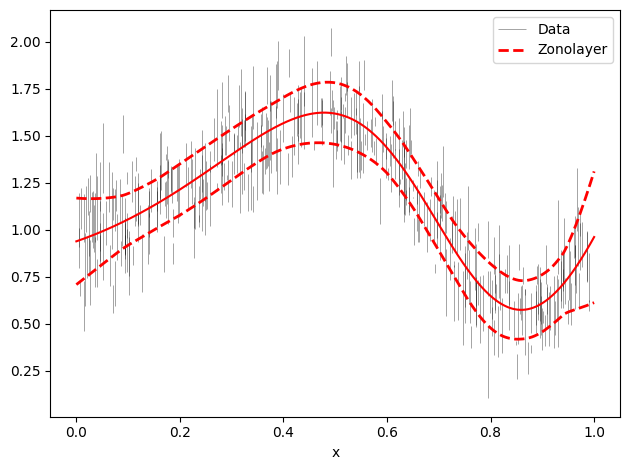

In [7]:
yl_zl = zonolayer["y_lower"]
yu_zl = zonolayer["y_upper"]
midpoint_model = zonolayer["midpoint"]

plt.figure()

x_plot = x_grid.squeeze()
sorted_idx = np.argsort(x_plot)

# x_data = x[sorted_idx].squeeze()
y_lower_data = y_lower[sorted_idx].squeeze()
y_upper_data = y_upper[sorted_idx].squeeze()

plt.vlines(x, y_lower_data, y_upper_data,
           color='black', alpha=0.5, linewidth=0.5, label='Data')

# Zonotope
plt.plot(x_plot, yl_zl, 'r--', lw=2, label='Zonolayer')
plt.plot(x_plot, yu_zl, 'r--', lw=2)

plt.plot(x_plot, midpoint_model, 'r-', lw=1.5)

plt.xlabel("x")
plt.legend()
plt.tight_layout()

plt.savefig("ArtificalDataset2.pdf", bbox_inches="tight")
plt.show()